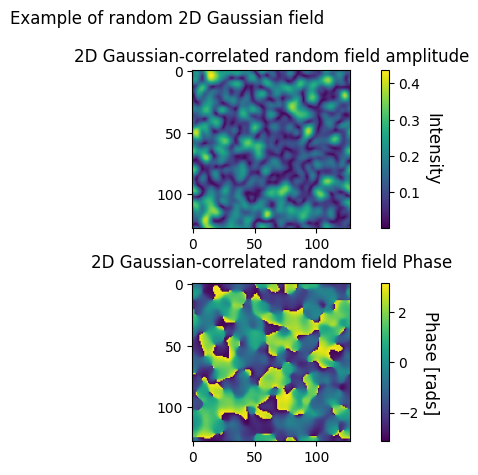

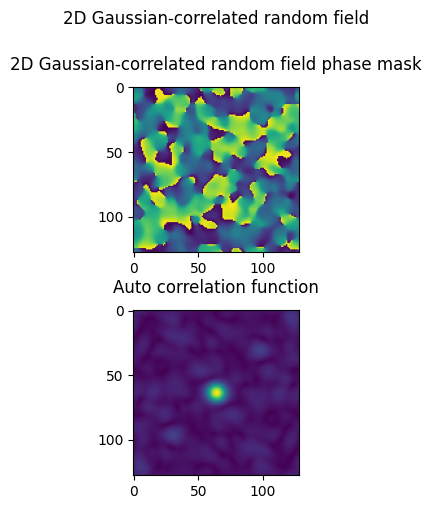

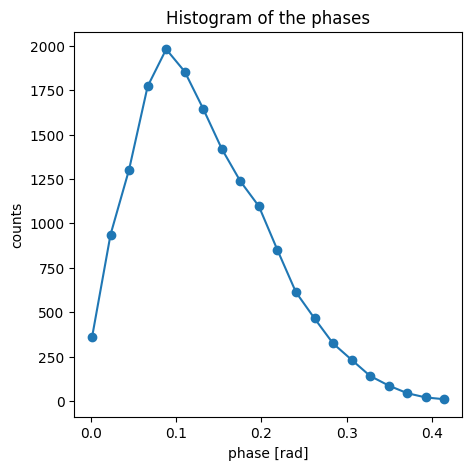

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_random_field(N, s,A):
    """
    Generate a 2D random field with Gaussian autocorrelation of variance s^2.

    N : int
        Size of the matrix (NxN).
    s : float
        Standard deviation of the Gaussian autocorrelation.
    A: amplitude in phase
    """
    # Frequency grid
    kx = np.fft.fftfreq(N)
    ky = np.fft.fftfreq(N)
    kx, ky = np.meshgrid(kx, ky)
    k2 = kx**2 + ky**2

    # Desired power spectrum ~ exp(- (s^2 * k^2)/2 )
    psd = np.exp(-0.5 * (s**2) * (2*np.pi)**2 * k2)

    # Random complex field with Gaussian spectrum
    noise = A * (np.random.normal(size=(N,N)) + 1j*np.random.normal(size=(N,N)))
    field_ft = noise * np.sqrt(psd)

    # Inverse FFT to get spatial field
    fieldR = np.fft.ifft2(field_ft).real
    fieldI = np.fft.ifft2(field_ft).imag

    return fieldR,fieldI

# Example usage
N = 128
s = 5.0
A = 190
fieldR, fieldI = gaussian_random_field(N, s,A)

F,A = plt.subplots(2,1)
F.suptitle('Example of random 2D Gaussian field')
i0 = A[0].imshow(np.sqrt(fieldR*fieldR + fieldI*fieldI), cmap="viridis")
cbar = plt.colorbar(i0, ax=A[0])
cbar.set_label("Intensity", fontsize=12)
cbar.ax.yaxis.label.set_rotation(270)
cbar.ax.yaxis.labelpad = 15   # increase spacing from the bar

A[0].set_title("2D Gaussian-correlated random field amplitude")
i1 = A[1].imshow(np.atan2(fieldI,fieldR), cmap="viridis")
cbar2 = plt.colorbar(i1, ax=A[1])
cbar2.set_label("Phase [rads]", fontsize=12)
cbar2.ax.yaxis.label.set_rotation(270)
cbar2.ax.yaxis.labelpad = 15   # increase spacing from the bar
A[1].set_title("2D Gaussian-correlated random field Phase",y=1.05)
plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.show()

########### NOW perform the 2D Autocorrelation pof the Phase

C_field = np.zeros(fieldR.shape, dtype=complex)
C_field.real = fieldR
C_field.imag = fieldI

Intensitaet = np.abs(C_field)
Hist,bins = np.histogram(Intensitaet.flatten(),bins=20)
### fft
F_C_field = np.fft.fft2(C_field)
ACF       = np.abs(np.fft.fftshift(np.fft.ifft2(F_C_field*np.conj(F_C_field))))

F1,A2 = plt.subplots(2,1)
F1.suptitle('2D Autocorrelation pof the Phase')
A2[0].imshow(np.atan2(C_field.imag,C_field.real), cmap="viridis")
A2[1].imshow(ACF, cmap="viridis")


F1.suptitle("2D Gaussian-correlated random field",y=1.05)
plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
A2[0].set_title("2D Gaussian-correlated random field phase mask",y=1.05)
A2[1].set_title("Auto correlation function",y=1.05)

plt.figure(figsize=(5,5))
plt.plot(bins[:-1],Hist,'o-')
plt.title('Histogram of the phases')
plt.xlabel('phase [rad]')
plt.ylabel('counts')

plt.show()


In [ ]:
inte1 = Intensitaet

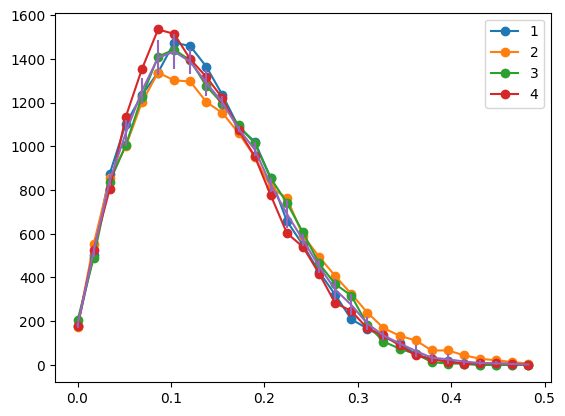

In [ ]:
BINS = np.linspace(0,0.5,30)

Hist1,bins1 = np.histogram(inte1.flatten(),bins=BINS)
Hist2,bins2 = np.histogram(inte2.flatten(),bins=BINS)
Hist3,bins3 = np.histogram(inte3.flatten(),bins=BINS)
Hist4,bins4 = np.histogram(inte4.flatten(),bins=BINS)
plt.figure()
plt.plot(bins1[:-1],Hist1,'o-',label="1")
plt.plot(bins2[:-1],Hist2,'o-',label="2")
plt.plot(bins3[:-1],Hist3,'o-',label="3")
plt.plot(bins4[:-1],Hist4,'o-',label="4")

Have = np.mean([Hist1,Hist2,Hist3,Hist4],axis=0)
Hstd = np.std([Hist1,Hist2,Hist3,Hist4],axis=0)

plt.errorbar(bins1[:-1],Have,yerr=Hstd)
plt.legend()
plt.show()
